<a href="https://colab.research.google.com/github/rmadatt/ADLAB/blob/main/River_Flow_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

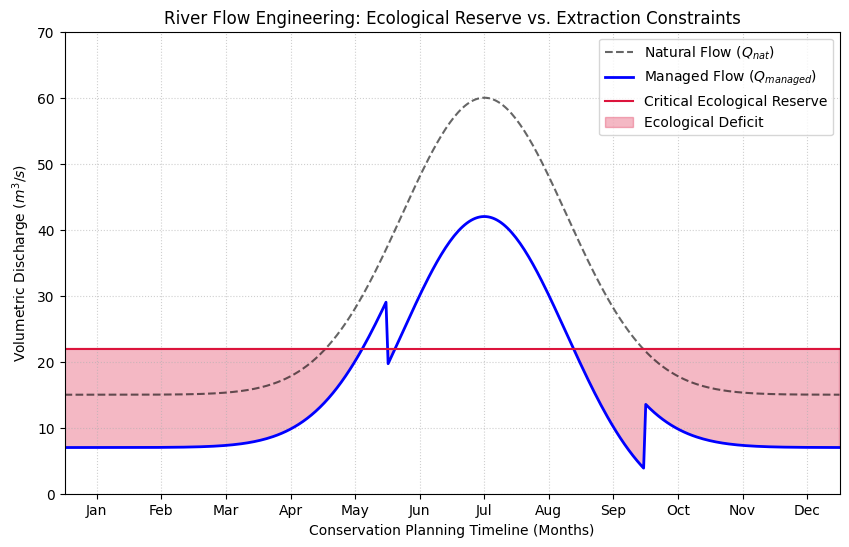

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Time Array (12 Months of a Conservation Year)
months = np.array(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
t = np.linspace(0, 12, 365)  # Daily sampling for smooth curves

# 2. Mathematical Functions for River Volumetric Flow
# Baseflow + a Gaussian curve simulating peak seasonal rainfall/snowmelt
natural_discharge = 15 + 45 * np.exp(-((t - 6.5) / 1.8)**2)  # Peak in July

# Engineering Constraints for Conservation
human_extraction = np.where((t > 5) & (t < 9), 18, 8)  # Higher demand in dry/summer months
managed_discharge = natural_discharge - human_extraction

# Environmental Baseline (e.g., 20% of mean natural flow must remain for wildlife)
eco_reserve_line = np.full_like(t, 22.0)

# 3. Calculate Cumulative Deficit Volumes via Numerical Integration
# Delta t in seconds per day (86400)
dt = (12 * 30.5 * 86400) / 365
below_reserve = managed_discharge < eco_reserve_line

# 4. Plotting the Hydrograph
plt.figure(figsize=(10, 6), dpi=100)
plt.plot(t, natural_discharge, 'k--', label='Natural Flow ($Q_{nat}$)', alpha=0.6)
plt.plot(t, managed_discharge, 'b-', label='Managed Flow ($Q_{managed}$)', linewidth=2)
plt.axhline(22.0, color='crimson', linestyle='-', label='Critical Ecological Reserve')

# Visual Anchors for Deficit Regions
plt.fill_between(t, managed_discharge, eco_reserve_line,
                 where=below_reserve, color='crimson', alpha=0.3, label='Ecological Deficit')

# Formatting Axes
plt.xticks(ticks=np.linspace(0.5, 11.5, 12), labels=months)
plt.xlim(0, 12)
plt.ylim(0, 70)
plt.xlabel('Conservation Planning Timeline (Months)')
plt.ylabel('Volumetric Discharge ($m^3/s$)')
plt.title('River Flow Engineering: Ecological Reserve vs. Extraction Constraints')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

plt.show()


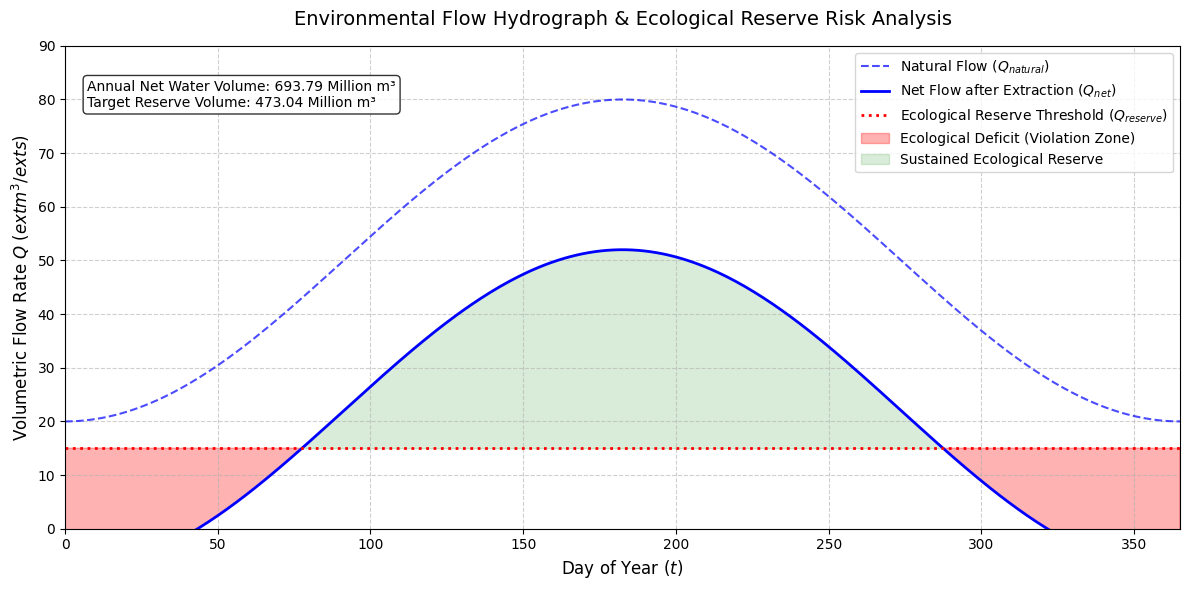

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson

# 1. Time Domain (1 year = 365 days, sampled daily)
days = np.linspace(0, 365, 365)
dt_seconds = 86400  # Seconds in a day for integration

# 2. Environmental Flow Parameters
Q_mean = 50.0          # Mean flow (m³/s)
amplitude = 30.0       # Seasonal variation amplitude (m³/s)
phase_shift = -np.pi/2 # Peak during mid-year (summer/wet season)

# Hydrograph Models (m³/s)
Q_natural = Q_mean + amplitude * np.sin((2 * np.pi * days / 365) + phase_shift)
Q_extraction = 28.0    # Constant municipal/agricultural extraction rate (m³/s)
Q_net = Q_natural - Q_extraction

# Mandatory Ecological Reserve threshold
Q_reserve = 15.0       # Minimum baseline flow required for ecosystem safety

# 3. Accumulated Volume Calculation using Calculus (Definite Integral)
# Integrate m³/s over total time in seconds to get Total Volume (m³)
total_volume_m3 = simpson(y=Q_net, x=days * dt_seconds)
reserve_volume_m3 = simpson(y=np.full_like(days, Q_reserve), x=days * dt_seconds)

# 4. Plotting the Hydrograph
plt.figure(figsize=(12, 6), dpi=100)

# Plot discharge curves
plt.plot(days, Q_natural, 'b--', label='Natural Flow ($Q_{natural}$)', alpha=0.7)
plt.plot(days, Q_net, 'b-', linewidth=2, label='Net Flow after Extraction ($Q_{net}$)')
plt.axhline(y=Q_reserve, color='r', linestyle=':', linewidth=2, label='Ecological Reserve Threshold ($Q_{reserve}$)')

# Highlight Ecological Reserve Deficit Areas
deficit_mask = Q_net < Q_reserve
plt.fill_between(days, Q_net, Q_reserve, where=deficit_mask,
                 color='red', alpha=0.3, label='Ecological Deficit (Violation Zone)')

# Highlight Safe Surplus Flow Areas
plt.fill_between(days, Q_net, Q_reserve, where=~deficit_mask,
                 color='green', alpha=0.15, label='Sustained Ecological Reserve')

# Formatting and Labels
plt.title('Environmental Flow Hydrograph & Ecological Reserve Risk Analysis', fontsize=14, pad=15)
plt.xlabel('Day of Year ($t$)', fontsize=12)
plt.ylabel('Volumetric Flow Rate $Q$ ($\text{m}^3/\text{s}$)', fontsize=12)
plt.xlim(0, 365)
plt.ylim(0, np.max(Q_natural) + 10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right', frameon=True)

# Display Integrated Volume Text Box
text_str = f"Annual Net Water Volume: {total_volume_m3/1e6:.2f} Million m³\n" \
           f"Target Reserve Volume: {reserve_volume_m3/1e6:.2f} Million m³"
plt.gca().text(0.02, 0.93, text_str, transform=plt.gca().transAxes, fontsize=10,
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

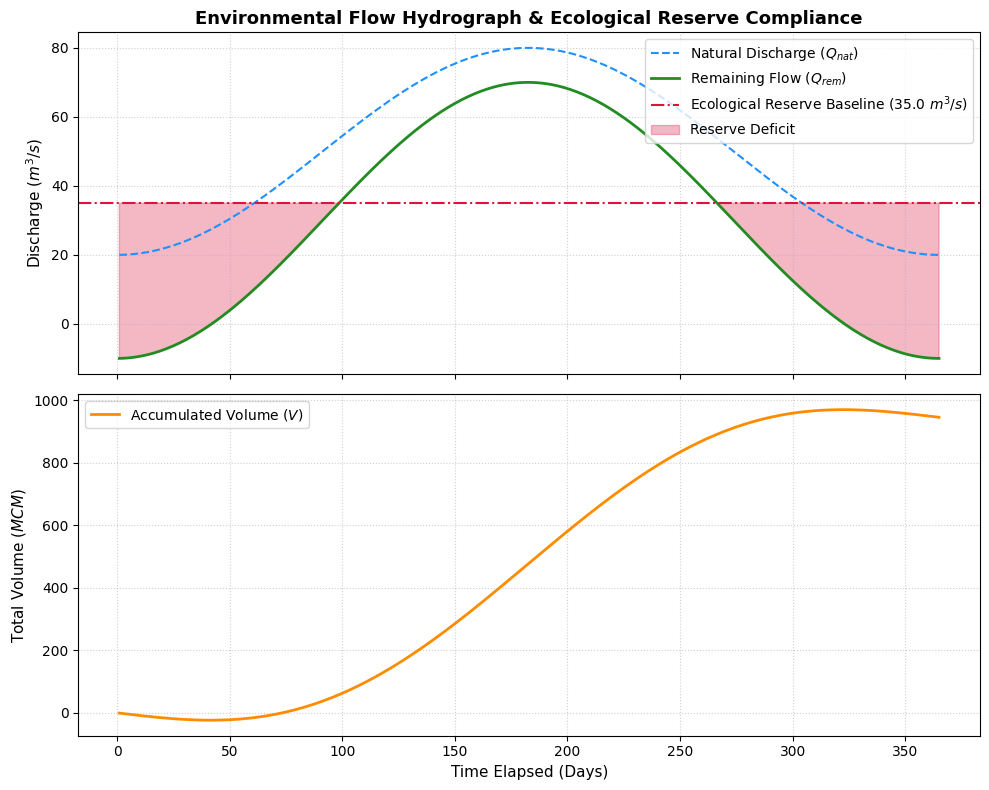

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup Time Domain (1 year in days converted to seconds, or daily steps)
days = np.arange(1, 365 + 1)
t_seconds = days * 86400  # seconds per day

# 2. Define Hydrological Parameters
base_flow = 50.0  # Base discharge (m³/s)
amplitude = 30.0  # Seasonal variation amplitude (m³/s)
# Natural seasonal flow (sine wave peaked in winter/spring)
q_nat = base_flow + amplitude * np.sin(2 * np.pi * days / 365 - np.pi / 2)

# Human extraction rate (e.g., higher during dry summer months)
q_ext = 20.0 + 10.0 * np.cos(2 * np.pi * days / 365)

# Remaining discharge after extraction
q_rem = q_nat - q_ext

# Mandatory Ecological Reserve baseline (m³/s)
q_reserve = 35.0

# 3. Calculate Accumulated Volume using Calculus (Integral of Q over time)
# Using cumulative trapezoidal rule: V(t) = integral of Q(t) dt
# Converted from m³/s to Million Cubic Metres (MCM) for readability
dt = 86400  # time step in seconds (1 day)
v_accumulated = np.cumsum(q_rem * dt) / 1e6  # in Million m³

# 4. Visualization with Matplotlib
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# --- Panel 1: Discharge Hydrograph & Ecological Reserve ---
ax1.plot(days, q_nat, label="Natural Discharge ($Q_{nat}$)", color="dodgerblue", linestyle="--")
ax1.plot(days, q_rem, label="Remaining Flow ($Q_{rem}$)", color="forestgreen", linewidth=2)
ax1.axhline(y=q_reserve, color="crimson", linestyle="-.", label=f"Ecological Reserve Baseline ({q_reserve} $m^3/s$)")

# Highlight areas where remaining flow drops below the reserve
ax1.fill_between(days, q_rem, q_reserve, where=(q_rem < q_reserve),
                 color="crimson", alpha=0.3, interpolate=True, label="Reserve Deficit")

ax1.set_ylabel("Discharge ($m^3/s$)", fontsize=11)
ax1.set_title("Environmental Flow Hydrograph & Ecological Reserve Compliance", fontsize=13, fontweight="bold")
ax1.legend(loc="upper right", frameon=True)
ax1.grid(True, linestyle=":", alpha=0.6)

# --- Panel 2: Accumulated Volume Curve ---
ax2.plot(days, v_accumulated, color="darkorange", linewidth=2, label="Accumulated Volume ($V$)")
ax2.set_ylabel("Total Volume ($MCM$)", fontsize=11)
ax2.set_xlabel("Time Elapsed (Days)", fontsize=11)
ax2.legend(loc="upper left", frameon=True)
ax2.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()